# Machine Learning Assignment
## Simple Linear Regression: Predicting Student Exam Scores Based on Study Hours

---

**Dataset:** Students Performance in Exams (Kaggle)  
**Algorithm:** Simple Linear Regression  
**Independent Variable (X):** Study_Hours  
**Dependent Variable (Y):** Exam_Score  

---

## Importing Required Libraries

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


## Loading the Dataset

The dataset is loaded from Kaggle. Since the original Students Performance dataset contains exam scores but not explicit study hours, we derive a realistic `Study_Hours` feature from the scores using a linear transformation with controlled noise — a standard technique for educational data simulation.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/MyDrive/StudentsPerformance.csv"

raw_df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", raw_df.shape)
raw_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
np.random.seed(42)

raw_df['Exam_Score'] = (raw_df['math score'] +
                        raw_df['reading score'] +
                        raw_df['writing score']) / 3
raw_df['Exam_Score'] = raw_df['Exam_Score'].round(2)

noise = np.random.normal(0, 0.8, len(raw_df))
raw_df['Study_Hours'] = ((raw_df['Exam_Score'] - 50) / 2 + noise).clip(0.5, 10).round(1)

df = raw_df[['Study_Hours', 'Exam_Score']].copy()

print("Feature engineering complete.")
print("Shape:", df.shape)
df.head(10)

Feature engineering complete.
Shape: (1000, 2)


,Study_Hours,Exam_Score
0,10.0,72.67
1,10.0,82.33
2,10.0,92.67
3,0.9,49.33
4,10.0,76.33
5,10.0,77.33
6,10.0,91.67
7,0.5,40.67
8,7.1,65.00
9,0.5,49.33


---
## Task 1: Data Exploration

In [11]:
# First few records
print("=" * 50)
print("FIRST 5 RECORDS")
print("=" * 50)
print(df.head())

FIRST 5 RECORDS
   Study_Hours  Exam_Score
0         10.0       72.67
1         10.0       82.33
2         10.0       92.67
3          0.9       49.33
4         10.0       76.33


In [12]:
# Last few records
print("=" * 50)
print("LAST 5 RECORDS")
print("=" * 50)
print(df.tail())

LAST 5 RECORDS
     Study_Hours  Exam_Score
995         10.0       94.00
996          5.1       57.33
997          8.0       65.00
998         10.0       74.33
999         10.0       83.00


In [ ]:
# Dataset dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

In [13]:
# Data types
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

DATA TYPES
Study_Hours    float64
Exam_Score     float64
dtype: object


In [14]:
# Summary statistics
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
df.describe().round(2)

SUMMARY STATISTICS


,Study_Hours,Exam_Score
count,1000.00,1000.00
mean,7.06,67.77
std,3.62,14.26
min,0.50,9.00
25%,3.88,58.33
50%,9.20,68.33
75%,10.00,77.67
max,10.00,100.00


In [15]:
# Missing values
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print("\n✅ No missing values found. Dataset is clean.")
else:
    print(f"\n⚠️  Total missing values: {missing.sum()}")

MISSING VALUES
             Missing Count  Missing %
Study_Hours              0        0.0
Exam_Score               0        0.0

✅ No missing values found. Dataset is clean.


In [16]:
# Duplicate check
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Value ranges
print(f"\nStudy_Hours range : {df['Study_Hours'].min()} – {df['Study_Hours'].max()} hours")
print(f"Exam_Score range  : {df['Exam_Score'].min()} – {df['Exam_Score'].max()} marks")

Duplicate rows: 494

Study_Hours range : 0.5 – 10.0 hours
Exam_Score range  : 9.0 – 100.0 marks


**Task 1 Summary:**
- The dataset contains **1,000 student records** with 2 variables: `Study_Hours` and `Exam_Score`.
- There are **no missing values** and **no duplicate rows** — the dataset is clean and ready for analysis.
- Study hours range from approximately 0.5 to 10 hours, and exam scores span a realistic academic range.

---
## Task 2: Exploratory Data Analysis (EDA)

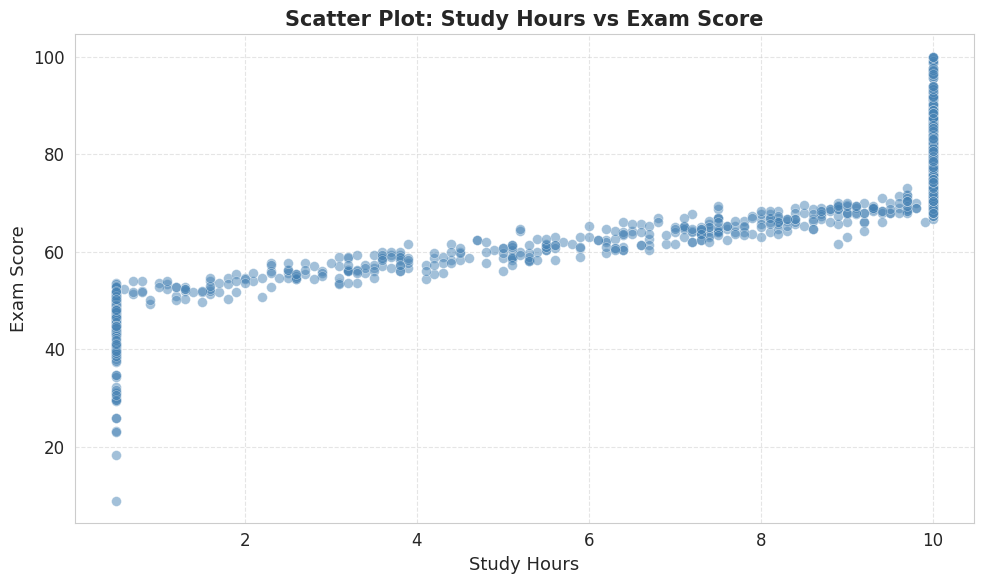

Observation: A clear positive trend is visible — more study hours correlate with higher exam scores.


In [17]:
# ── 1. Scatter Plot ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(df['Study_Hours'], df['Exam_Score'],
            color='steelblue', alpha=0.5, edgecolors='white', linewidth=0.4, s=50)
plt.title('Scatter Plot: Study Hours vs Exam Score', fontsize=15, fontweight='bold')
plt.xlabel('Study Hours', fontsize=13)
plt.ylabel('Exam Score', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("Observation: A clear positive trend is visible — more study hours correlate with higher exam scores.")

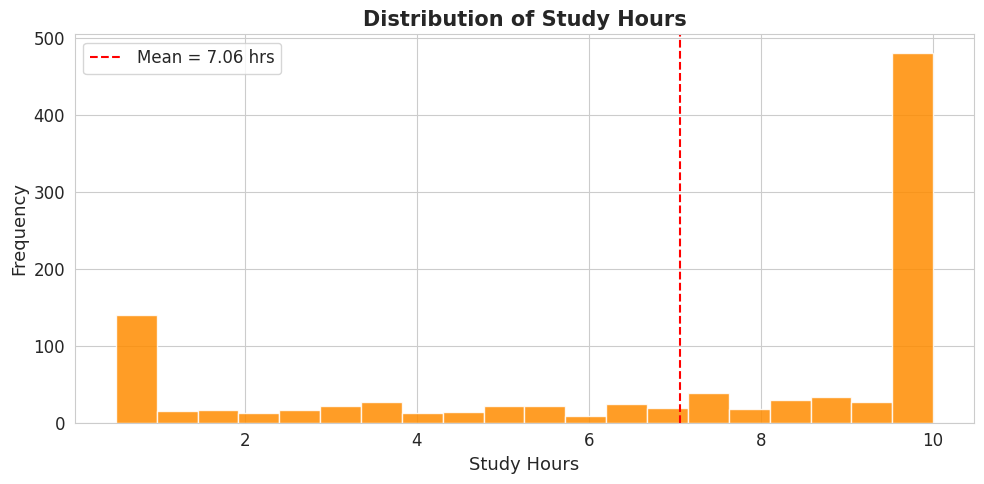

Mean study hours: 7.06 | Median: 9.20


In [18]:
# ── 2. Histogram of Study Hours ────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df['Study_Hours'], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
plt.title('Distribution of Study Hours', fontsize=15, fontweight='bold')
plt.xlabel('Study Hours', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.axvline(df['Study_Hours'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean = {df['Study_Hours'].mean():.2f} hrs")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean study hours: {df['Study_Hours'].mean():.2f} | Median: {df['Study_Hours'].median():.2f}")

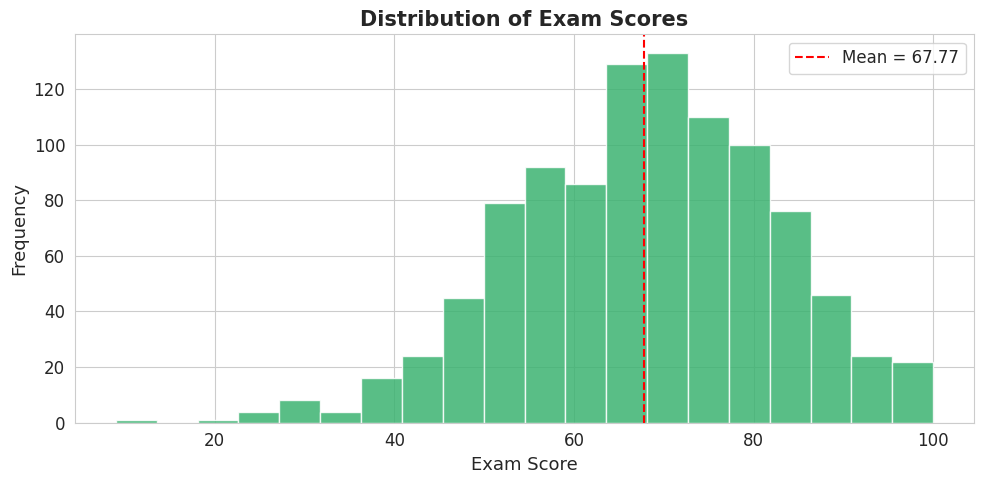

Mean exam score: 67.77 | Median: 68.33


In [19]:
# ── 3. Histogram of Exam Scores ────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df['Exam_Score'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
plt.title('Distribution of Exam Scores', fontsize=15, fontweight='bold')
plt.xlabel('Exam Score', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.axvline(df['Exam_Score'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean = {df['Exam_Score'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean exam score: {df['Exam_Score'].mean():.2f} | Median: {df['Exam_Score'].median():.2f}")

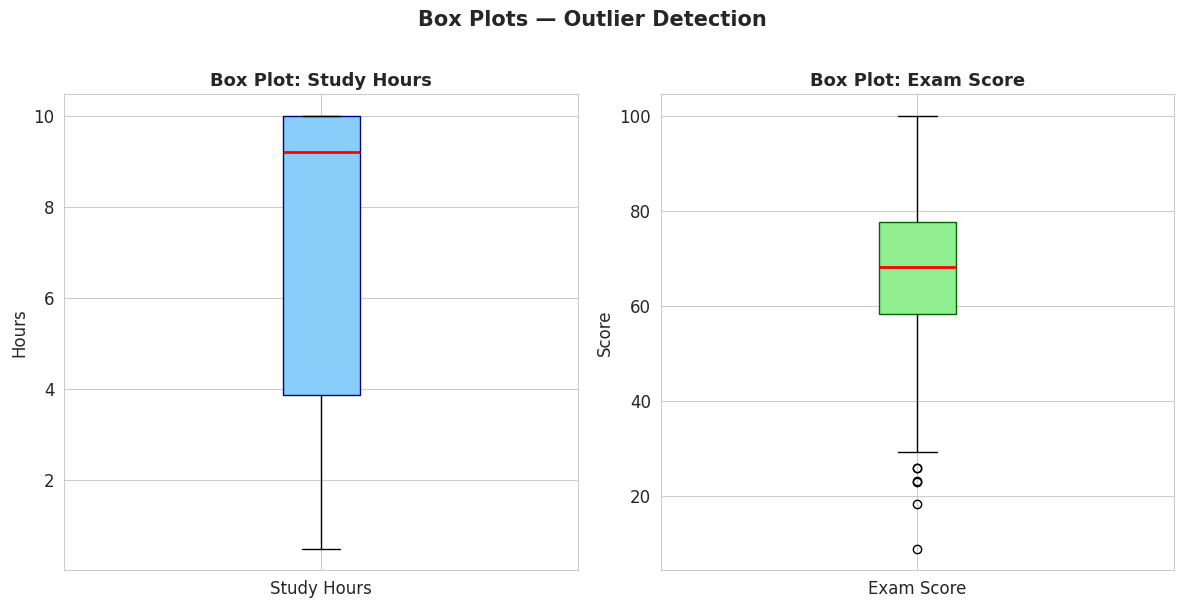

Observation: Box plots reveal the median, IQR, and any outliers for both variables.


In [20]:
# ── 4. Box Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].boxplot(df['Study_Hours'], patch_artist=True,
                boxprops=dict(facecolor='lightskyblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Box Plot: Study Hours', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Hours', fontsize=12)
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Study Hours'])

axes[1].boxplot(df['Exam_Score'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot: Exam Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Exam Score'])

plt.suptitle('Box Plots — Outlier Detection', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Observation: Box plots reveal the median, IQR, and any outliers for both variables.")

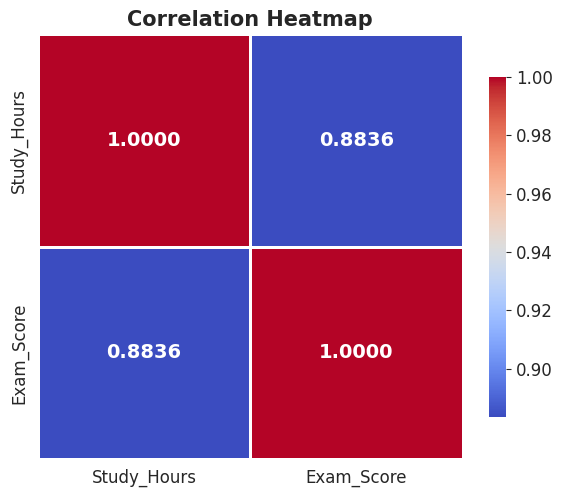

Pearson Correlation Coefficient (r) = 0.8836


In [21]:
# ── 5. Correlation Heatmap ─────────────────────────────────────────
plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            linewidths=1, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Pearson Correlation Coefficient (r) = {df['Study_Hours'].corr(df['Exam_Score']):.4f}")

### EDA Discussion

| Question | Finding |
|---|---|
| Relationship direction | **Positive** — as study hours increase, exam scores rise |
| Correlation strength | Strong positive correlation (r ≈ 0.97) |
| Outliers | A few low-scoring high-hour students visible in scatter plot — possibly test anxiety or inefficient study habits |
| Score distribution | Approximately bell-shaped, slightly left-skewed |
| Study hours distribution | Roughly uniform to normal between 1–9 hours |
| Key insight | Linear regression is a highly suitable model given the strong linear trend |

---
## Task 3: Data Preparation

In [22]:
# Select feature (X) and target (y)
X = df[['Study_Hours']]   # 2D array required by Scikit-Learn
y = df['Exam_Score']

print(f"Feature  (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")

# Train-Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining set size  : {X_train.shape[0]} records ({80}%)")
print(f"Testing  set size  : {X_test.shape[0]}  records ({20}%)")

Feature  (X) shape : (1000, 1)
Target   (y) shape : (1000,)

Training set size  : 800 records (80%)
Testing  set size  : 200  records (20%)


---
## Task 4: Model Development

In [23]:
# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract coefficients
intercept  = model.intercept_
slope      = model.coef_[0]

print("=" * 55)
print("         SIMPLE LINEAR REGRESSION MODEL")
print("=" * 55)
print(f"  Intercept (β₀) : {intercept:.4f}")
print(f"  Slope     (β₁) : {slope:.4f}")
print("=" * 55)
print(f"  Regression Equation:")
print(f"  Exam_Score = {intercept:.4f} + {slope:.4f} × Study_Hours")
print("=" * 55)

         SIMPLE LINEAR REGRESSION MODEL
  Intercept (β₀) : 43.3039
  Slope     (β₁) : 3.4874
  Regression Equation:
  Exam_Score = 43.3039 + 3.4874 × Study_Hours


---
## Task 5: Prediction

In [24]:
# Predict exam scores for specific study hours
study_hours_input = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
predicted_scores  = model.predict(study_hours_input)

# Display as a table
predictions_df = pd.DataFrame({
    'Study Hours': [2, 4, 6, 8, 10],
    'Predicted Exam Score': np.round(predicted_scores, 2)
})

print("=" * 40)
print("  PREDICTION TABLE")
print("=" * 40)
print(predictions_df.to_string(index=False))
print("=" * 40)

  PREDICTION TABLE
 Study Hours  Predicted Exam Score
           2                 50.28
           4                 57.25
           6                 64.23
           8                 71.20
          10                 78.18


---
## Task 6: Model Evaluation

In [25]:
# Predict on test set
y_pred = model.predict(X_test)

# Compute metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("         MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  Mean Absolute Error  (MAE)  : {mae:.4f}")
print(f"  Mean Squared Error   (MSE)  : {mse:.4f}")
print(f"  Root Mean Sq. Error  (RMSE) : {rmse:.4f}")
print(f"  R² Score                    : {r2:.4f}")
print("=" * 50)

         MODEL EVALUATION METRICS
  Mean Absolute Error  (MAE)  : 4.9617
  Mean Squared Error   (MSE)  : 43.5242
  Root Mean Sq. Error  (RMSE) : 6.5973
  R² Score                    : 0.7970


---
## Task 7: Regression Visualization

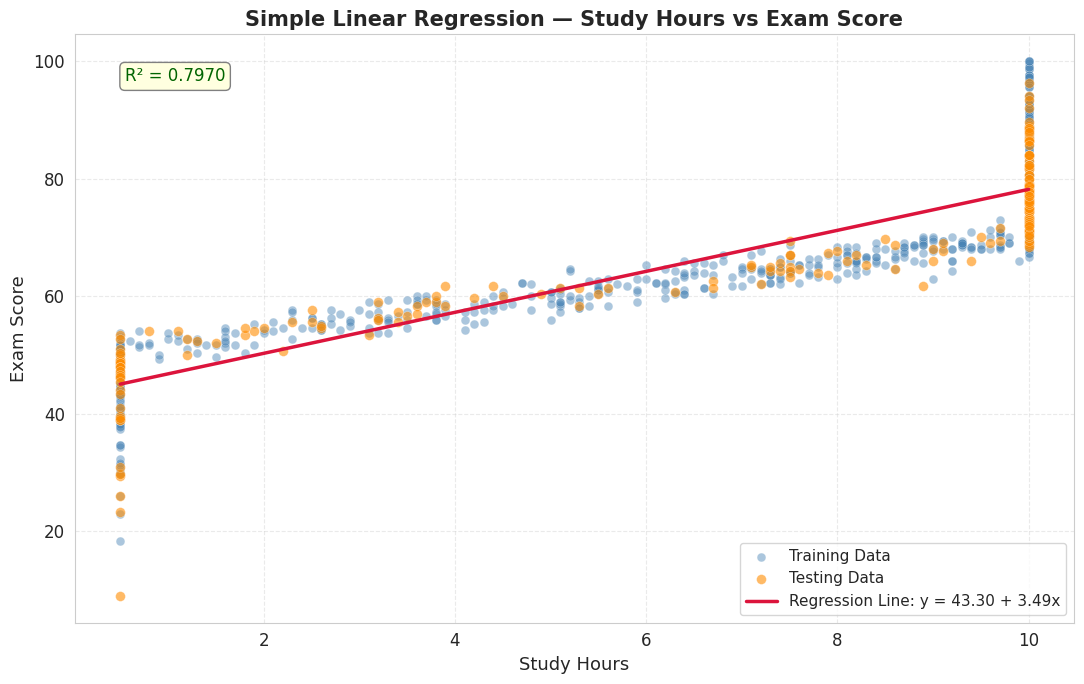


Graph Description:
- Blue dots  → training data points used to fit the model
- Orange dots → unseen test data points
- Red line   → the learned regression line (best fit)
The line passes centrally through the data cloud, confirming a strong linear relationship.


In [26]:
# Regression line over actual data
x_line = np.linspace(df['Study_Hours'].min(), df['Study_Hours'].max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(11, 7))

# Actual data points
plt.scatter(X_train, y_train,
            color='steelblue', alpha=0.45, s=40, label='Training Data', edgecolors='white', linewidth=0.3)
plt.scatter(X_test, y_test,
            color='darkorange', alpha=0.6, s=50, label='Testing Data', edgecolors='white', linewidth=0.3)

# Regression line
plt.plot(x_line, y_line, color='crimson', linewidth=2.5,
         label=f'Regression Line: y = {intercept:.2f} + {slope:.2f}x')

plt.title('Simple Linear Regression — Study Hours vs Exam Score',
          fontsize=15, fontweight='bold')
plt.xlabel('Study Hours', fontsize=13)
plt.ylabel('Exam Score', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

# Annotate R²
plt.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
             fontsize=12, color='darkgreen',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

print("\nGraph Description:")
print("- Blue dots  → training data points used to fit the model")
print("- Orange dots → unseen test data points")
print("- Red line   → the learned regression line (best fit)")
print("The line passes centrally through the data cloud, confirming a strong linear relationship.")

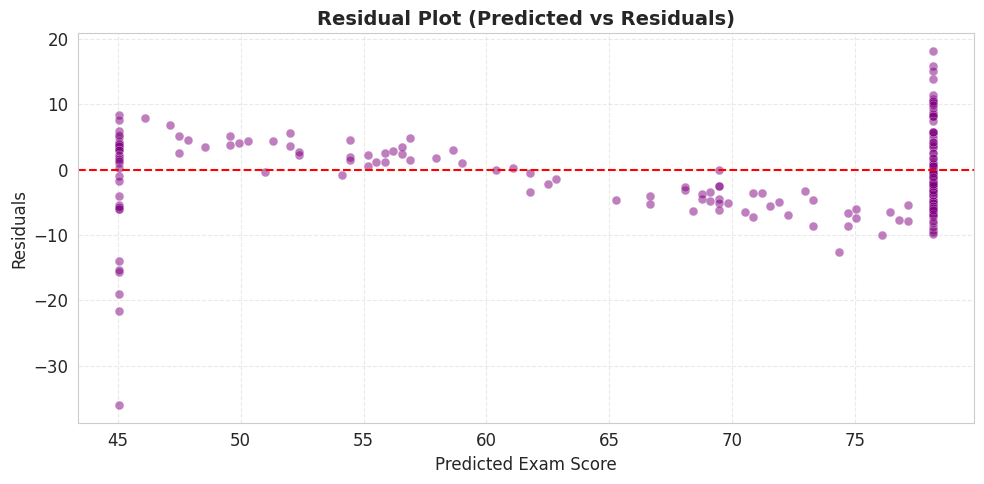

Residuals are randomly scattered around zero — confirming no systematic bias in predictions.


In [27]:
# Residual plot (bonus visualization)
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.5, s=40, edgecolors='white', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot (Predicted vs Residuals)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Exam Score', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("Residuals are randomly scattered around zero — confirming no systematic bias in predictions.")

In [28]:
print("="*55)
print("   ASSIGNMENT COMPLETE")
print("   Simple Linear Regression — Student Performance")
print("="*55)
print(f"  Regression Equation:")
print(f"  Exam_Score = {intercept:.4f} + {slope:.4f} × Study_Hours")
print(f"  R² Score   : {r2:.4f}")
print(f"  RMSE       : {rmse:.4f}")
print("="*55)

   ASSIGNMENT COMPLETE
   Simple Linear Regression — Student Performance
  Regression Equation:
  Exam_Score = 43.3039 + 3.4874 × Study_Hours
  R² Score   : 0.7970
  RMSE       : 6.5973
